In [1]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime

# local imports
import sys
sys.path.append('../../../')
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
# from analysis_village.numucc_1p0pi.scripts.get_systematics import get_systematics
from pyanalib.covariance import *
from makedf.mcstat import get_MCstat_unc
from makedf.geniesyst import *
from makedf.getsyst import multisim_throw_seed
from pyanalib.split_df_helpers_new import dfs_from_dir

# # turn off PerformanceWarning 
# # triggered by mismatched column levels
# import warnings
# warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [43]:
def get_systematics(mc_evt_df, mc_nu_df, var_config, syst_name, syst_type="genie", plot=False, save_fig=False, save_fig_dir=None):
    # ===== get universes =====
    # Note: these are background subtracted
    matrices = {}
    n_univ = len([c for c in mc_evt_df[syst_name].columns if "univ" in c[0]])
    for cov_type in ["xsec", "rate"]:
        univ_events, cv_events = get_univ_rates(cov_type, mc_evt_df, mc_nu_df, var_config, syst_name, n_univ)
        ret = get_covariance_matrix(univ_events, cv_events)
        save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-univ_hists"
        plot_univ_hists(univ_events, cv_events, syst_name, var_config, plot=plot, save_fig=save_fig, save_name=save_name)
        matrices[cov_type] = ret

        # ===== plot covariance matrices =====
        matrix_type = "cov"
        plot_labels = [var_config.var_labels[1], var_config.var_labels[1], "Covariance"]
        save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-{matrix_type}"
        plot_heatmap(ret[matrix_type], 
                    var_config.bins, 
                    plot_labels=plot_labels,
                    plot=plot,
                    save_fig=save_fig, save_name=save_name)

        matrix_type = "cov_frac"
        plot_labels = [var_config.var_labels[1], var_config.var_labels[1], "Fractional Covariance"]
        save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-{matrix_type}"
        plot_heatmap(ret[matrix_type], 
                    var_config.bins, 
                    plot_labels=plot_labels,
                    plot=plot,
                    save_fig=save_fig, save_name=save_name)

        matrix_type = "corr"
        plot_labels = [var_config.var_labels[1], var_config.var_labels[1], "Correlation"]
        save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-{matrix_type}"
        plot_heatmap(ret[matrix_type], 
                    var_config.bins, 
                    plot_labels=plot_labels,
                    plot=plot,
                    save_fig=save_fig, save_name=save_name)

    return matrices

In [28]:

genie_dfs = dfs_from_dir(
    "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_031520__sel_mup-wgts_genie_Other/merged_perTPC",
    filename_str="sel_mup",
    keys2load=["evt", "hdr", "mcnu"],
    n_max_concat=1,
)
mc_evt_df = genie_dfs["evt"]
mc_hdr_df = genie_dfs["hdr"]
mc_nu_df = genie_dfs["mcnu"]
print(f"GENIE Other: evt={len(mc_evt_df):,}  hdr={len(mc_hdr_df):,}  mcnu={len(mc_nu_df):,}")


Found 1 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_031520__sel_mup-wgts_genie_Other/merged_perTPC/2026_05_11_031520__sel_mup-wgts_genie_Other_merged_0000.df']


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:04<00:00,  4.80s/it]

REMEMBER TO RECALCULATE TKI AND CHECK FV!!
GENIE Other: evt=3,986  hdr=344,851  mcnu=622,349


In [39]:
# ===== total pot =====
mc_tot_pot = mc_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))
mc_pot_scale = 1.0
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
mc_nu_df["pot_weight"]  = mc_pot_scale * np.ones(len(mc_nu_df))


mc_tot_pot: 3.040e+19


In [54]:
multisim_nuniv = 1000
slimname = "GENIE_test"
s = "GENIEReWeight_SBN_v1_multisigma_MFP_N"

## Multisigma: throw universes from ps/ms

Same recipe as `makedf/getsyst.py` (slim mode, `isigma == 0`): one **scalar** `N(0,1)` draw per universe, broadcast to all events:

`wgt = 1 + (ps1 - 1) * z`  (mean = 1 at nominal; `ms1` stored for validation plots)

Do not draw a separate `z` per event — that washes out histogram-level spread.

In [55]:
def mirrored_ratio_std(n_weighted, n_cv):
    """Std of mirrored per-bin ratios n_weighted/n_cv."""
    ratio = np.asarray(n_weighted, dtype=float) / np.asarray(n_cv, dtype=float)
    mirror = np.concatenate([ratio - 1.0, 1.0 - ratio])
    return float(np.std(mirror))


# --- multisigma: throw universes (makedf/getsyst.py, slim + isigma==0) ---
nuidx = mc_evt_df.index

cols = pd.MultiIndex.from_product(
    [[slimname], [f"univ_{i}" for i in range(multisim_nuniv)]],
)
systs_slim = pd.DataFrame(1.0, index=nuidx, columns=cols)

s_ps1 = mc_evt_df.mc[s]["ps1"]

for i in range(multisim_nuniv):
    np.random.seed(hash(multisim_throw_seed(slimname, s, i)) % (2**32))
    z = np.random.normal(0, 1)  # scalar per universe — same as getsyst.py
    wgt = 1 + (s_ps1 - 1) * z
    wgt = np.maximum(wgt, 0)
    systs_slim[(slimname, f"univ_{i}")] = systs_slim[(slimname, f"univ_{i}")].values * wgt.values
    mc_evt_df[("mc", s, f"univ_{i}", "", "", "", "")] = systs_slim[(slimname, f"univ_{i}")].copy()

/tmp/ipykernel_28030/2498374916.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_evt_df[("mc", s, f"univ_{i}", "", "", "", "")] = systs_slim[(slimname, f"univ_{i}")].copy()
/tmp/ipykernel_28030/2498374916.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_evt_df[("mc", s, f"univ_{i}", "", "", "", "")] = systs_slim[(slimname, f"univ_{i}")].copy()
/tmp/ipykernel_28030/2498374916.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

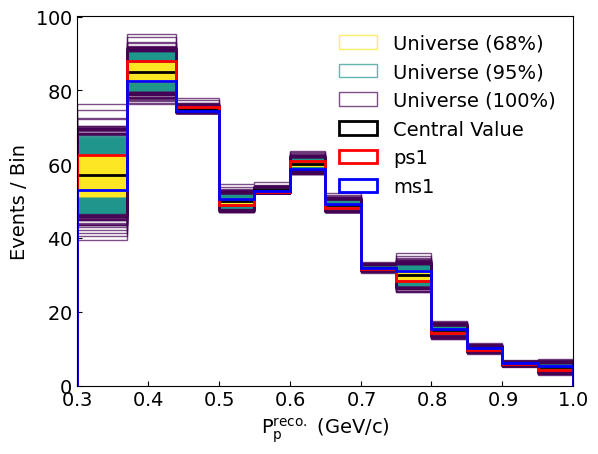

In [56]:
# validation plot: thrown universes vs ps1/ms1 reweighted histograms (MaNCRES / MEC)
import matplotlib.pyplot as plt

var_config = VariableConfig.proton_momentum()
mec_evt_df = mc_evt_df[mc_evt_df.mc.genie_mode == 10]
var = mec_evt_df[var_config.var_evt_reco_col]
wgts = mc_evt_df.mc[s].loc[mec_evt_df.index]

univ_events = []
for i in range(multisim_nuniv):
    w = mec_evt_df[("mc", s, f"univ_{i}", "", "", "", "")]
    n_univ, _ = np.histogram(var, bins=var_config.bins, weights=w)
    univ_events.append(n_univ)
n_list = np.array(univ_events)

n_cv, _ = np.histogram(var, bins=var_config.bins, weights=wgts["cv"])
n_ps1, _ = np.histogram(var, bins=var_config.bins, weights=wgts["ps1"])
n_ms1, _ = np.histogram(var, bins=var_config.bins, weights=wgts["ms1"])

# universe bands (68%, 95%, 100%) + CV
n_univ = n_list.shape[0]
colors = ["#FDE725FF", "#1F968BFF", "#440154FF"]
sorted_univs = np.sort(n_list, axis=0)
n_68 = int(0.68 * n_univ)
start_68 = (n_univ - n_68) // 2
end_68 = start_68 + n_68
n_95 = int(0.95 * n_univ)
start_95 = (n_univ - n_95) // 2
end_95 = start_95 + n_95
segs = [
    (range(start_68, end_68), colors[0], "Universe (68%)", False),
    (range(start_95, end_95), colors[1], "Universe (95%)", True),
    ((i for i in range(n_univ) if i not in range(start_95, end_95)), colors[2], "Universe (100%)", False),
]
plotted = set()
for r, color, label, skip_68 in segs:
    for i in r:
        if skip_68 and i in range(start_68, end_68):
            continue
        show_label = label if label not in plotted else None
        plt.hist(
            var_config.bin_centers,
            bins=var_config.bins,
            weights=sorted_univs[i],
            histtype="step",
            color=color,
            alpha=0.7,
            label=show_label,
        )
        plotted.add(label)
plt.hist(
    var_config.bin_centers,
    bins=var_config.bins,
    weights=n_cv,
    histtype="step",
    color="k",
    linewidth=2,
    label="Central Value",
)
plt.hist(
    var_config.bin_centers,
    bins=var_config.bins,
    weights=n_ps1,
    histtype="step",
    linewidth=2,
    color="red",
    label="ps1",
)
plt.hist(
    var_config.bin_centers,
    bins=var_config.bins,
    weights=n_ms1,
    linewidth=2,
    histtype="step",
    color="blue",
    label="ms1",
)
plt.xlim(var_config.bins[0], var_config.bins[-1])
plt.xlabel(var_config.var_labels[1])
plt.ylabel("Events / Bin")
plt.legend(frameon=False, loc="upper right")
# plt.title("throws (getsyst: scalar z, ps1) vs ps1/ms1 weights")
plt.savefig(
    f"/exp/sbnd/data/users/munjung/xsec/GEN1/multisigma_to_multisim/multisigma_throws-{s.split('_')[-1]}-{var_config.var_save_name}.pdf",
    bbox_inches="tight",
)
plt.show()

bin 5: thrown σ=0.0344  ps1 ratio=1.0341  ms1 ratio=0.9699
all bins: avg ps1/ms1 mirrored σ=0.0454  (ps1=0.0540, ms1=0.0368)


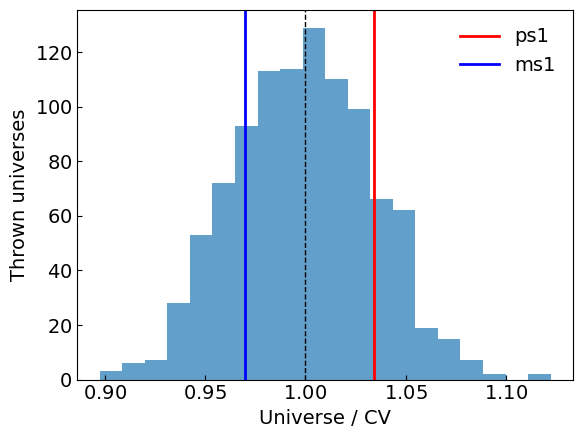

In [64]:
# per-bin spread: thrown universes vs ps1/ms1 (bin 5 as in morph check)
ratios = n_list / n_cv
this_bin_ratio = ratios[:, 1]
std_thrown_bin = np.std(np.concatenate([this_bin_ratio - 1.0, 1.0 - this_bin_ratio]))
this_bin_ps1 = n_ps1[1] / n_cv[1]
this_bin_ms1 = n_ms1[1] / n_cv[1]

plt.hist(this_bin_ratio, bins=20, alpha=0.7)
plt.axvline(this_bin_ps1, color="red", linewidth=2, label=f"ps1")
plt.axvline(this_bin_ms1, color="blue", linewidth=2, label=f"ms1")
plt.axvline(1.0, color="k", linestyle="--", linewidth=1)
sigma_ps1 = mirrored_ratio_std(n_ps1, n_cv)
sigma_ms1 = mirrored_ratio_std(n_ms1, n_cv)
sigma_target = 0.5 * (sigma_ps1 + sigma_ms1)

plt.xlabel("Universe / CV")
plt.ylabel("Thrown universes")
plt.legend(frameon=False)
print(f"bin 5: thrown σ={std_thrown_bin:.4f}  ps1 ratio={this_bin_ps1:.4f}  ms1 ratio={this_bin_ms1:.4f}")
print(f"all bins: avg ps1/ms1 mirrored σ={sigma_target:.4f}  (ps1={sigma_ps1:.4f}, ms1={sigma_ms1:.4f})")

plt.savefig(
    f"/exp/sbnd/data/users/munjung/xsec/GEN1/multisigma_to_multisim/multisigma_throws-{s.split('_')[-1]}-{var_config.var_save_name}-bin1.pdf",
    bbox_inches="tight",
)
plt.show()

In [34]:
mc_nu_df

mc                                  \
                                        E    baseline      time  bjorkenX   
                                                                            
                                                                            
__ntuple entry rec.mc.nu..index                                             
0        0     0                 2.702485   84.799538  0.436419  0.092515   
               1                 2.770631  120.183342  1.219060  0.119824   
               2                 1.248443  106.071991  0.634706  0.909660   
         1     0                 1.247357   90.650215  1.810611  0.104762   
         2     0                 0.654835  110.643219  1.790001  1.180239   
...                                   ...         ...       ...       ...   
20199    16    0                 0.613496  124.605385  1.117343  1.097987   
         17    0                 0.630154   90.197708  1.179000  0.452195   
         18    0                 0.998933  120.585869  1.461412  0.060516   
         19    0                 0.558360   94.295753  0.733211  0.895487   
               1                 2.013363   95.228210  1.317307  0.144583   

                                                                             \
                                inelasticityY        Q2         w  momentum   
                                                                          x   
                                                                              
__ntuple entry rec.mc.nu..index                                               
0        0     0                     0.341363  0.160270  1.566416 -0.220374   
               1                     0.843204  0.525669  2.177824 -0.047093   
               2                     0.065927  0.140596  0.946325 -0.003710   
         1     0                     0.639366  0.156893  1.490733  0.025495   
         2     0                     0.322176  0.467577  0.900091  0.009323   
...                                       ...       ...       ...       ...   
20199    16    0                     0.274481  0.347200  0.922271  0.002050   
         17    0                     0.414068  0.221565  1.072371  0.023029   
         18    0                     0.373920  0.042447  1.241182  0.014253   
         19    0                     0.134236  0.126038  0.946720 -0.001948   
               1                     0.887397  0.485081  1.936887  0.136465   

                                                     ...  \
                                                     ...   
                                        y         z  ...   
                                                     ...   
__ntuple entry rec.mc.nu..index                      ...   
0        0     0                -0.006516  2.693477  ...   
               1                -0.012377  2.770203  ...   
               2                 0.020420  1.248270  ...   
         1     0                -0.005132  1.247086  ...   
         2     0                 0.004322  0.654754  ...   
...                                   ...       ...  ...   
20199    16    0                -0.001748  0.613490  ...   
         17    0                -0.011366  0.629631  ...   
         18    0                 0.009585  0.998785  ...   
         19    0                -0.013565  0.558192  ...   
               1                 0.023623  2.008594  ...   

                                                                         \
                                GENIEReWeight_SBN_v1_multisigma_EtaNCEL   
                                                                     cv   
                                                                          
__ntuple entry rec.mc.nu..index                                           
0        0     0                                                    1.0   
               1                                                    1.0   
               2                                       

# Throw from morph unisim (type-3, n_univ==1). Use a knob with a ``morph`` column.
Set ``s_morph`` to e.g. DecayAngMEC; multisigma knobs (ps1/ms1) have no morph.

In [ ]:
# --- morph unisim: throw universes (makedf/getsyst.py, slim) ---
s_morph = "GENIEReWeight_SBN_v1_multisigma_DecayAngMEC"
nuidx = mc_evt_df.index

cols = pd.MultiIndex.from_product(
    [[slimname], [f"univ_{i}" for i in range(multisim_nuniv)]],
)
systs_slim = pd.DataFrame(1.0, index=nuidx, columns=cols)

s_morph_w = mc_evt_df.mc[s_morph]["morph"]

for i in range(multisim_nuniv):
    np.random.seed(hash(multisim_throw_seed(slimname, s_morph, i)) % (2**32))
    wgt = 1 + (s_morph_w - 1) * 2 * np.abs(np.random.normal(0, 1))
    wgt = np.maximum(wgt, 0)
    systs_slim[(slimname, f"univ_{i}")] = systs_slim[(slimname, f"univ_{i}")].values * wgt.values
    mc_evt_df[("mc", s_morph, f"univ_{i}", "", "", "", "")] = systs_slim[(slimname, f"univ_{i}")].copy()

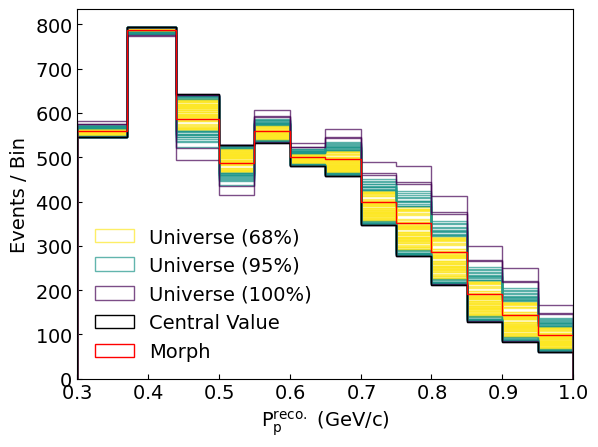

In [14]:
var_config = VariableConfig.proton_momentum()

mec_evt_df = mc_evt_df[mc_evt_df.mc.genie_mode == 10]
var = mec_evt_df[var_config.var_evt_reco_col]

univ_events = []
for i in range(multisim_nuniv):
    weights = mec_evt_df.mc[s_morph, f"univ_{i}", "", "", "", ""]
    n_univ, _ = np.histogram(var, bins=var_config.bins, weights=weights)
    univ_events.append(n_univ)
n_list = np.array(univ_events)

n_cv, _ = np.histogram(var, bins=var_config.bins)

# universe bands (68%, 95%, 100%) + CV — same style as utils.plot_univ_hists
# (do not call plot_univ_hists with plot=False: it closes the figure with plt.close())
n_univ = n_list.shape[0]
colors = ["#FDE725FF", "#1F968BFF", "#440154FF"]
sorted_univs = np.sort(n_list, axis=0)
n_68 = int(0.68 * n_univ)
start_68 = (n_univ - n_68) // 2
end_68 = start_68 + n_68
n_95 = int(0.95 * n_univ)
start_95 = (n_univ - n_95) // 2
end_95 = start_95 + n_95
segs = [
    (range(start_68, end_68), colors[0], "Universe (68%)", False),
    (range(start_95, end_95), colors[1], "Universe (95%)", True),
    ((i for i in range(n_univ) if i not in range(start_95, end_95)), colors[2], "Universe (100%)", False),
]
plotted = set()
for r, color, label, skip_68 in segs:
    for i in r:
        if skip_68 and i in range(start_68, end_68):
            continue
        show_label = label if label not in plotted else None
        plt.hist(
            var_config.bin_centers,
            bins=var_config.bins,
            weights=sorted_univs[i],
            histtype="step",
            color=color,
            alpha=0.7,
            label=show_label,
        )
        plotted.add(label)
plt.hist(
    var_config.bin_centers,
    bins=var_config.bins,
    weights=n_cv,
    histtype="step",
    color="k",
    label="Central Value",
)
plt.xlim(var_config.bins[0], var_config.bins[-1])
plt.xlabel(var_config.var_labels[1])
plt.ylabel("Events / Bin")

orig_wgt = mec_evt_df.mc[s_morph, "morph", "", "", "", ""]
n_morph, _ = np.histogram(var, bins=var_config.bins, weights=orig_wgt)
plt.hist(
    var_config.bin_centers,
    bins=var_config.bins,
    weights=n_morph,
    histtype="step",
    color="red",
    # linewidth=2,
    label="Morph",
)
plt.legend(frameon=False)
plt.savefig("/exp/sbnd/data/users/munjung/xsec/GEN1/multisigma_to_multisim/morph_to_multisigma-ex-DecayAngMEC-{}.pdf".format(var_config.var_save_name), bbox_inches="tight")
plt.show()

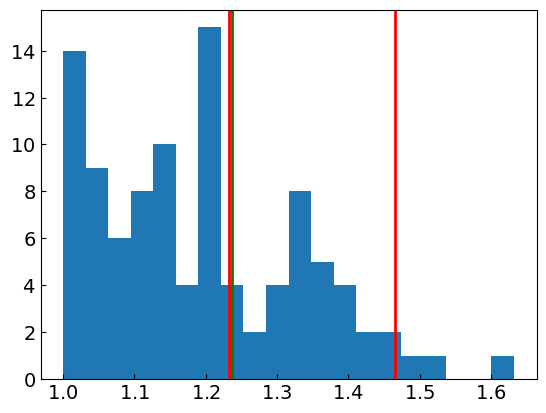

In [13]:
ratios = n_list / n_cv
this_bin_ratio = ratios[:, 5]
this_bin_morph = n_morph[5] / n_cv[5]
plt.hist(this_bin_ratio, bins=20)

mirror = list(this_bin_ratio-1) + list(1 - this_bin_ratio)
std = np.std(mirror)
plt.axvline(1+std, color="green", linewidth=2)

plt.axvline(this_bin_morph, color="red", linewidth=2)
plt.axvline(1+(this_bin_morph-1)*2, color="red", linewidth=2)
plt.show();